Part 1 (Guided): You'll work through a complete machine learning workflow step-by-step with detailed code and explanations. We'll use the breast cancer dataset to predict whether a tumor is malignant (cancerous) or benign (non-cancerous).



In [1]:
"""
Breast Cancer Prediction with KNN
Author: [Barsha]
Description: Predict whether a breast tumor is malignant or benign using KNN
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
 
# Load the breast cancer dataset
print("Loading breast cancer dataset...")
cancer_data = load_breast_cancer()
 
# The dataset is a Bunch object with 'data', 'target', 'feature_names', etc.
print(f"\nDataset type: {type(cancer_data)}")
print(f"Number of samples: {len(cancer_data.data)}")
print(f"Number of features: {len(cancer_data.feature_names)}")
print(f"Target classes: {cancer_data.target_names}")
 
# Convert to DataFrame for easier manipulation
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target
 
print("\nFirst few rows:")
print(df.head())
 
print("\nDataset info:")
print(df.info())
 
print("\nTarget distribution:")
print(df['target'].value_counts())
print(f"Malignant (1): {(df['target'] == 1).sum()}")
print(f"Benign (0): {(df['target'] == 0).sum()}")

Loading breast cancer dataset...

Dataset type: <class 'sklearn.utils._bunch.Bunch'>
Number of samples: 569
Number of features: 30
Target classes: ['malignant' 'benign']

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520


BASIC STATISTICS
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.0

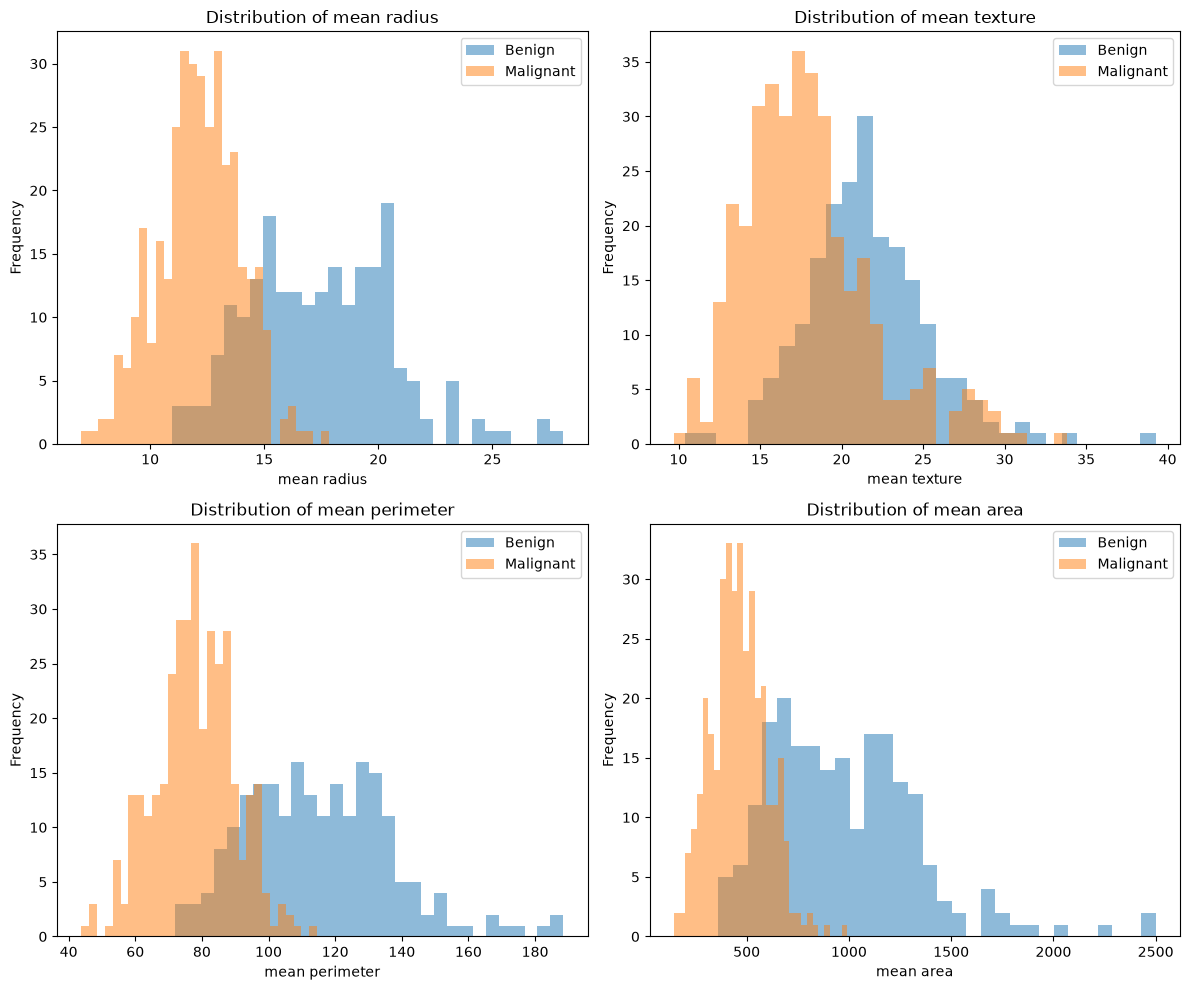

In [2]:
# Basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df.describe())
 
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])
 
# Visualize feature distributions (select a few key features)
print("\n" + "="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)
 
# Select a few representative features to visualize
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
 
for idx, feature in enumerate(key_features):
    axes[idx].hist(df[df['target'] == 0][feature], alpha=0.5, label='Benign', bins=30)
    axes[idx].hist(df[df['target'] == 1][feature], alpha=0.5, label='Malignant', bins=30)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].legend()
 
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'feature_distributions.png'")
plt.show()

In [4]:
# Separate features and target
X = df.drop('target', axis=1)  # All columns except 'target'
y = df['target']  # Target column
 
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
 
# Split into training and testing sets
# random_state ensures reproducibility
# stratify=y ensures both sets have similar class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
 
print("\n" + "="*50)
print("DATA SPLIT")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training features: {X_train.shape[1]}")
print(f"Test features: {X_test.shape[1]}")
 
# Verify class distribution in both sets
print("\nTraining set target distribution:")
print(y_train.value_counts())
print(f"  Benign (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
 
print("\nTest set target distribution:")
print(y_test.value_counts())
print(f"  Benign (0): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

Features shape: (569, 30)
Target shape: (569,)

DATA SPLIT
Training set size: 455 samples
Test set size: 114 samples
Training features: 30
Test features: 30

Training set target distribution:
target
1    285
0    170
Name: count, dtype: int64
  Benign (0): 170 (37.4%)
  Malignant (1): 285 (62.6%)

Test set target distribution:
target
1    72
0    42
Name: count, dtype: int64
  Benign (0): 42 (36.8%)
  Malignant (1): 72 (63.2%)


In [6]:
# Create KNN classifier
# n_neighbors=5 means the model will look at the 5 nearest neighbors to make a prediction
 
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
 
print("KNN classifier trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")

KNN classifier trained successfully!
Number of neighbors (k): 5


In [7]:
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
 
print(f"\nTraining predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")    


Training predictions: 455
Test predictions: 114


In [8]:
# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
 
print("=== Model Performance ===")
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nTest Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
 
print("\n=== Confusion Matrix ===")
print("                Predicted")
print("              Benign  Malignant")
print(f"Actual Benign    {test_confusion[0,0]:4d}      {test_confusion[0,1]:4d}")
print(f"      Malignant  {test_confusion[1,0]:4d}      {test_confusion[1,1]:4d}")
 
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=cancer_data.target_names))

=== Model Performance ===

Training Accuracy: 0.9473 (94.73%)
Test Accuracy: 0.9123 (91.23%)

Test Precision: 0.9429
Test Recall: 0.9167

=== Confusion Matrix ===
                Predicted
              Benign  Malignant
Actual Benign      38         4
      Malignant     6        66

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.86      0.90      0.88        42
      benign       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114




EXPERIMENTING WITH DIFFERENT K VALUES
K= 1: Accuracy=0.9211, Precision=0.9565, Recall=0.9167
K= 3: Accuracy=0.9298, Precision=0.9444, Recall=0.9444
K= 5: Accuracy=0.9123, Precision=0.9429, Recall=0.9167
K= 7: Accuracy=0.9298, Precision=0.9444, Recall=0.9444
K= 9: Accuracy=0.9386, Precision=0.9452, Recall=0.9583
K=11: Accuracy=0.9386, Precision=0.9452, Recall=0.9583

Best K value: 9 (Accuracy: 0.9386)

Saved visualization to 'knn_k_comparison.png'


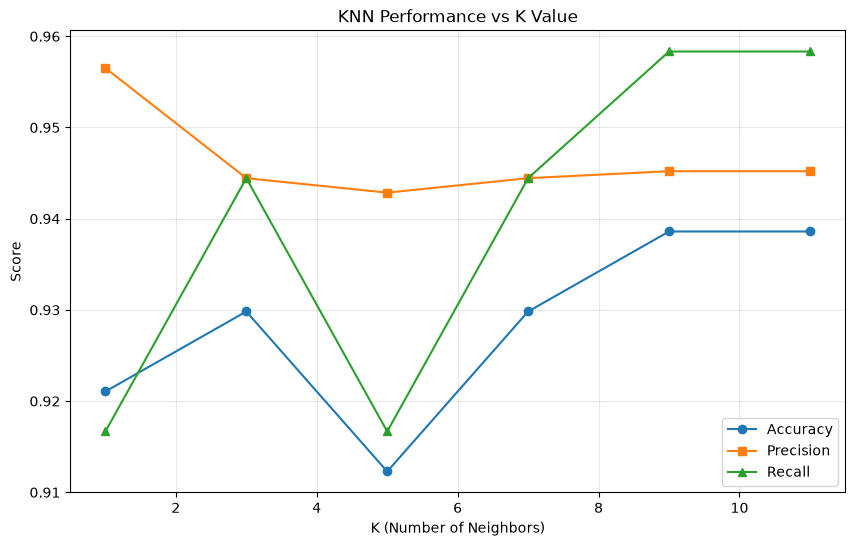

In [9]:
# Experiment with different K values
print("\n" + "="*50)
print("EXPERIMENTING WITH DIFFERENT K VALUES")
print("="*50)
 
k_values = [1, 3, 5, 7, 9, 11]
results = []
 
for k in k_values:
    # Create and train model
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    
    # Make predictions
    y_pred_temp = knn_temp.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp)
    
    results.append({
        'K': k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec
    })
    
    print(f"K={k:2d}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")
 
# Find best K
results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['Accuracy'].idxmax(), 'K']
print(f"\nBest K value: {best_k} (Accuracy: {results_df['Accuracy'].max():.4f})")
 
# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['K'], results_df['Precision'], marker='s', label='Precision')
plt.plot(results_df['K'], results_df['Recall'], marker='^', label='Recall')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Score')
plt.title('KNN Performance vs K Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('knn_k_comparison.png', dpi=150, bbox_inches='tight')
print("\nSaved visualization to 'knn_k_comparison.png'")
plt.show()

Part 2: Unguided Exercise - Customer Churn Prediction

In [11]:
import pandas as pd
file_path = r"C:\Users\bbars\Desktop\Week 1\Day3\lab-sklearn-model-training\WA_Fn-UseC_-Telco-Customer-Churn.xls"
telco_df = pd.read_csv(file_path)
print(telco_df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

Structure of the data:

In [12]:
print("Shape:", telco_df.shape)
print()
print("Columns:", list(telco_df.columns))
print()
telco_df.info()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-nu

Missing Values:

In [13]:
print(telco_df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Target Distribution

In [14]:
print(telco_df["Churn"].value_counts())
print()
print(telco_df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


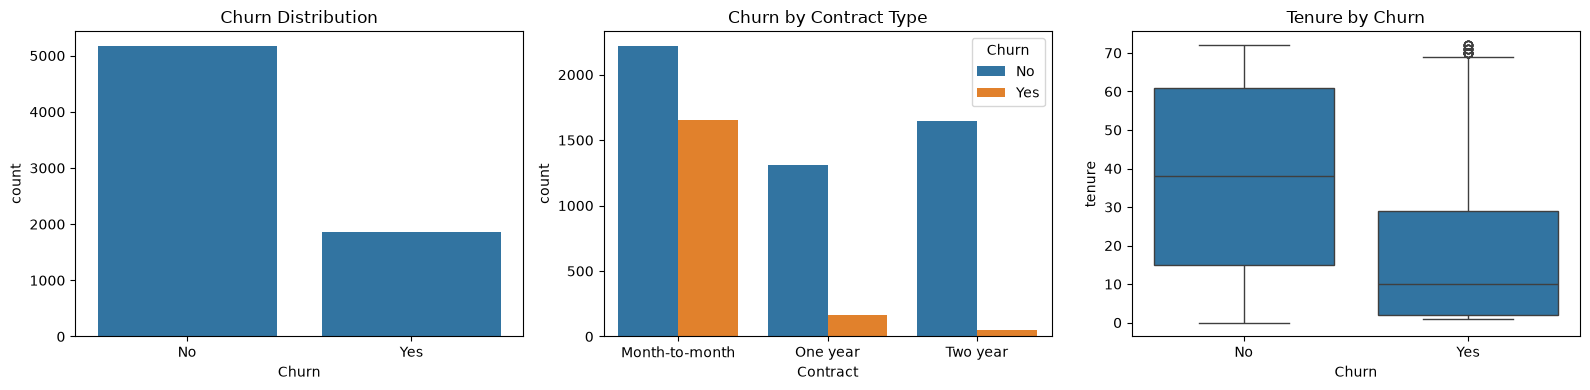

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=telco_df, x="Churn", ax=axes[0])
axes[0].set_title("Churn Distribution")

sns.countplot(data=telco_df, x="Contract", hue="Churn", ax=axes[1])
axes[1].set_title("Churn by Contract Type")

sns.boxplot(data=telco_df, x="Churn", y="tenure", ax=axes[2])
axes[2].set_title("Tenure by Churn")

plt.tight_layout()
plt.show()

Step 2: Data Preprocessing

In [19]:
telco_df["TotalCharges"] = pd.to_numeric(telco_df["TotalCharges"], errors="coerce")
print(telco_df["TotalCharges"].isnull().sum())

telco_df = telco_df.drop(columns=["customerID"])
telco_df["Churn"] = telco_df["Churn"].map({"No": 0, "Yes": 1})
print(telco_df["Churn"].value_counts())

y = telco_df["Churn"]
X = telco_df.drop(columns=["Churn"])

X = pd.get_dummies(X, drop_first=True, dtype=int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print(X.dtypes.value_counts())
X.head()

11
Churn
0    5174
1    1869
Name: count, dtype: int64
X shape: (7043, 30)
y shape: (7043,)

int64      28
float64     2
Name: count, dtype: int64


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


Step 3: Split the Data

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Training set:", X_train.shape, y_train.shape)
print("Test set:    ", X_test.shape, y_test.shape)
print()
print("Churn rate in training set:", round(y_train.mean() * 100, 1), "%")
print("Churn rate in test set:    ", round(y_test.mean() * 100, 1), "%")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set: (5625, 30) (5625,)
Test set:     (1407, 30) (1407,)

Churn rate in training set: 26.6 %
Churn rate in test set:     26.6 %


In [21]:
print(X.isnull().sum().sum())


11


In [22]:
rows_ok = X.notnull().all(axis=1)
X = X[rows_ok]
y = y[rows_ok]
print(X.shape, y.shape)

(7032, 30) (7032,)


Step 4: Train a KNN Model

In [24]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print("Model trained")
sample_predictions = knn.predict(X_test_scaled[:10])
print("Predicted:", sample_predictions)
print("Actual:   ", y_test.values[:10])

Model trained
Predicted: [0 1 0 0 0 1 0 0 1 0]
Actual:    [0 0 0 1 0 1 0 0 1 0]


Step 5: Make Predictions and Evaluate

Accuracy:  0.754
Precision: 0.537
Recall:    0.537
[[860 173]
 [173 201]]


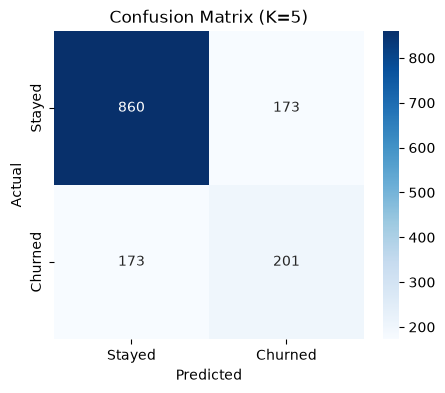

              precision    recall  f1-score   support

      Stayed       0.83      0.83      0.83      1033
     Churned       0.54      0.54      0.54       374

    accuracy                           0.75      1407
   macro avg       0.68      0.68      0.68      1407
weighted avg       0.75      0.75      0.75      1407



In [25]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Churned"],
            yticklabels=["Stayed", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (K=5)")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

Step 6: Experiment and Improve

    K  Accuracy  Precision  Recall
0   1     0.725      0.484   0.511
1   3     0.744      0.518   0.545
2   5     0.754      0.537   0.537
3   7     0.749      0.528   0.532
4   9     0.765      0.559   0.553
5  11     0.770      0.569   0.548
6  15     0.771      0.573   0.543


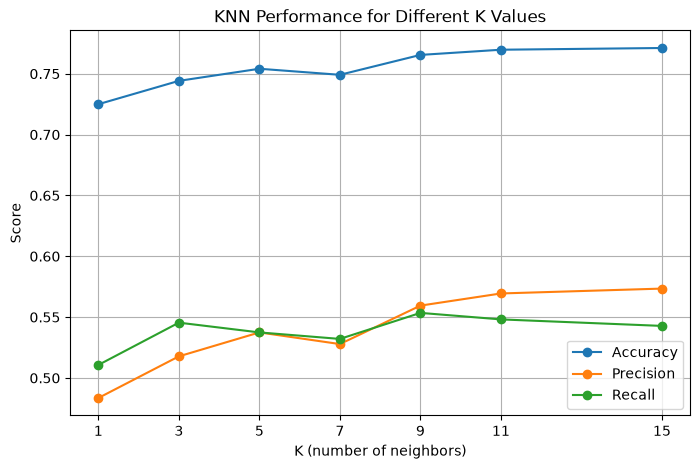

Best K by accuracy: 15
K            15.000
Accuracy      0.771
Precision     0.573
Recall        0.543
Name: 6, dtype: float64


In [26]:
k_values = [1, 3, 5, 7, 9, 11, 15]
results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    results.append({
        "K": k,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
    })

results_df = pd.DataFrame(results)
print(results_df.round(3))

plt.figure(figsize=(8, 5))
plt.plot(results_df["K"], results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(results_df["K"], results_df["Precision"], marker="o", label="Precision")
plt.plot(results_df["K"], results_df["Recall"], marker="o", label="Recall")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Score")
plt.title("KNN Performance for Different K Values")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

best_row = results_df.loc[results_df["Accuracy"].idxmax()]
print("Best K by accuracy:", int(best_row["K"]))
print(best_row.round(3))

Findings here:

I tested K values from 1 to 15. Accuracy improved from 72.5% at K=1 to about 77% at K=11 and K=15, while recall peaked at 55.3% at K=9. Because the gains in accuracy flatten out after K=9 and recall is highest there, I chose K=9 as a balance between overall accuracy and catching churners.

In [29]:
final_knn = KNeighborsClassifier(n_neighbors=9)
final_knn.fit(X_train_scaled, y_train)
final_pred = final_knn.predict(X_test_scaled)
print(classification_report(y_test, final_pred, target_names=["Stayed", "Churned"]))

              precision    recall  f1-score   support

      Stayed       0.84      0.84      0.84      1033
     Churned       0.56      0.55      0.56       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.76      0.77      0.77      1407



Step 7: Analysis and Recommendations


Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: Churn, dtype: float64

PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn, dtype: float64

TechSupport
No                     41.6
Yes                    15.2
No internet service     7.4
Name: Churn, dtype: float64

OnlineSecurity
No                     41.8
Yes                    14.6
No internet service     7.4
Name: Churn, dtype: float64

PaperlessBilling
Yes    33.6
No     16.3
Name: Churn, dtype: float64

       tenure  MonthlyCharges  TotalCharges
Churn                                      
0        37.6            61.3        2555.3
1        18.0            74.4        1531.8


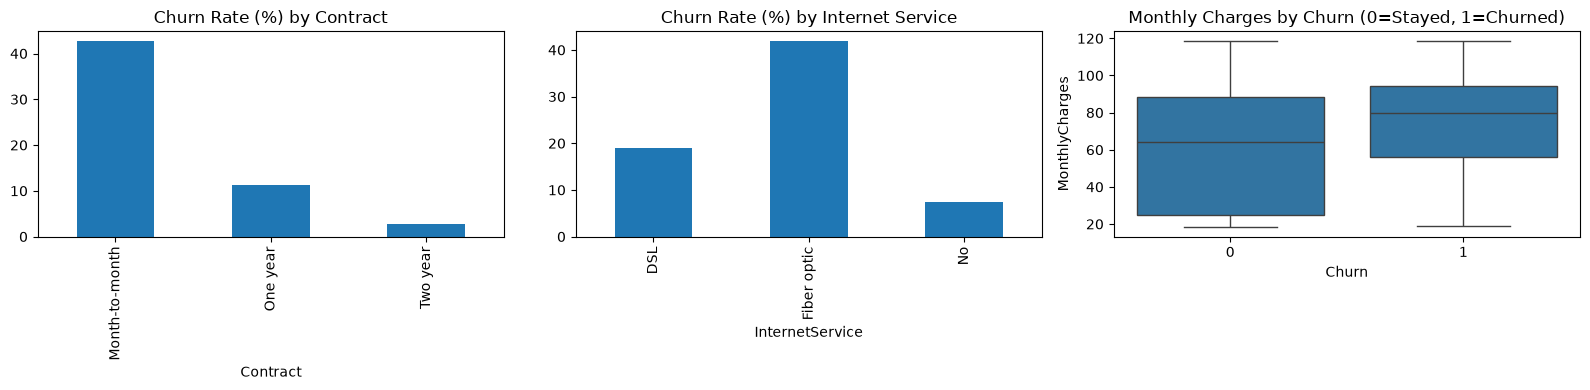

In [30]:
cols = ["Contract", "InternetService", "PaymentMethod",
        "TechSupport", "OnlineSecurity", "PaperlessBilling"]

for col in cols:
    rates = (telco_df.groupby(col)["Churn"].mean() * 100).round(1)
    print(rates.sort_values(ascending=False))
    print()

print(telco_df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

(telco_df.groupby("Contract")["Churn"].mean() * 100).plot(kind="bar", ax=axes[0])
axes[0].set_title("Churn Rate (%) by Contract")

(telco_df.groupby("InternetService")["Churn"].mean() * 100).plot(kind="bar", ax=axes[1])
axes[1].set_title("Churn Rate (%) by Internet Service")

sns.boxplot(data=telco_df, x="Churn", y="MonthlyCharges", ax=axes[2])
axes[2].set_title("Monthly Charges by Churn (0=Stayed, 1=Churned)")

plt.tight_layout()
plt.show()

Findings:

### 1. What is the model's accuracy?

My final KNN model uses K=9, chosen from the values 1, 3, 5, 7, 9, 11 and 15. I picked K=9 because it had the highest recall (0.553) and its accuracy (0.765) was within 0.006 of the best score (0.771 at K=15). The model's accuracy is about **77%**.

However, accuracy alone is misleading here. About 73.4% of customers in the test set stayed, so a model that always predicted "stayed" would already score 73.4%. My model is only about 3 to 4 points better than that baseline.

| Class | Precision | Recall | F1-score |
|---|---|---|---|
| Stayed | 0.84 | 0.84 | 0.84 |
| Churned | 0.56 | 0.55 | 0.56 |

The model is much better at identifying customers who stay than customers who leave. When it predicts churn it is right about 56% of the time, and it catches about 55% of the customers who actually churn.

### 2. Which features seem most important?

KNN has no built-in feature importance, so I compared churn rates across groups. The overall churn rate is about 26.5%.

| Feature | Higher-churn group | Lower-churn group |
|---|---|---|
| Contract | Month-to-month: 42.7% | One year: 11.3%, two year: 2.8% |
| Internet service | Fiber optic: 41.9% | DSL: 19.0%, no internet: 7.4% |
| Payment method | Electronic check: 45.3% | Other methods: 15.2% to 19.1% |
| Tech support | No: 41.6% | Yes: 15.2% |
| Online security | No: 41.8% | Yes: 14.6% |
| Paperless billing | Yes: 33.6% | No: 16.3% |

Numeric features also differ. Customers who churned had an average tenure of 18.0 months, compared with 37.6 months for those who stayed, and they paid more per month on average ($74.4 compared with $61.3).

Contract type shows the biggest gap: month-to-month customers churn about 15 times as often as two-year customers. Short tenure, fiber optic service, electronic check payment, and the lack of tech support or online security are also strong signals.

These patterns show association, not cause. Several features probably overlap (for example, month-to-month customers may also be the ones paying by electronic check), so I can't tell which feature has the strongest independent effect.

### 3. Recommendations for the company

1. **Move month-to-month customers to longer contracts** using discounts or perks, since they are the highest-risk group.
2. **Focus retention efforts on new customers**, especially in the first year or two, because churners leave after about 18 months on average.
3. **Investigate fiber optic service.** Its churn rate is more than double DSL's, which could be due to price, reliability, or competition. This data cannot tell us which.
4. **Promote tech support and online security bundles.** Customers without them churn at about 42%, compared with about 15% for those who have them.
5. **Encourage automatic payment methods** instead of electronic checks, which have the highest churn rate (45.3%).
6. **Use the model to flag at-risk customers** for targeted retention offers, but not as the only decision tool, since it misses a large share of churners.

### 4. Limitations of the model

- It misses many churners. Recall is only about 55%, so almost half of the customers who leave are not flagged.
- It barely beats the baseline. Accuracy of 77% compares with 73.4% for always predicting "stayed".
- The data is imbalanced. Only about 26.5% of customers churned, which pushes the model toward predicting "stayed". Class weighting or resampling could help.
- KNN treats all features equally. Important features such as contract type and tenure get no extra weight, and the many 0/1 columns created by encoding add noise.
- K was chosen using the test set, so the reported scores may be slightly optimistic. Cross-validation on the training data would be more reliable.
- Even values of K can cause voting ties. When I tried K=10, ties defaulted to "stayed" and recall dropped to 0.47, so I used an odd K.
- KNN is hard to interpret. It does not show which features drive a prediction, so I relied on group comparisons.
- Features overlap, so the group comparisons cannot separate their individual effects.
- The data is a single snapshot from one company, so the results may not apply to other companies or time periods.
- Better models likely exist. Logistic regression, decision trees, or random forests would probably give better recall and clearer feature importance.